# Bivariate Analysis

Bivariate analysis examines the relationship between two variables.

In this project, our primary objective is to understand how different features influence the target variable `claim`.

We will analyze:

1. Numerical vs Claim
   - Age vs Claim
   - BMI vs Claim

2. Categorical vs Claim
   - Smoker vs Claim
   - Diabetic vs Claim
   - Gender vs Claim
   - Region vs Claim


## Age vs Claim

Objective:
To examine whether claim amount increases with age.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_clean= pd.read_csv("C:\\Users\\Ali\\Desktop\\first eda project\\nootebooks\\final_clean_datas.csv")

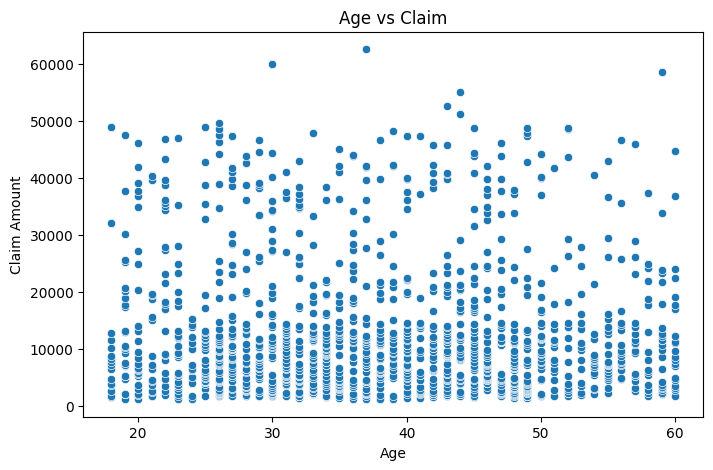

In [3]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="age", y="claim", data=df_clean)
plt.title("Age vs Claim")
plt.xlabel("Age")
plt.ylabel("Claim Amount")
plt.show()


In [4]:
import dtale
import pandas as pd

df_clean= pd.read_csv("C:\\Users\\Ali\\Desktop\\first eda project\\nootebooks\\final_clean_datas.csv")

# Assigning a reference to a running D-Tale proce
d = dtale.show(df_clean)
d.open_browser()

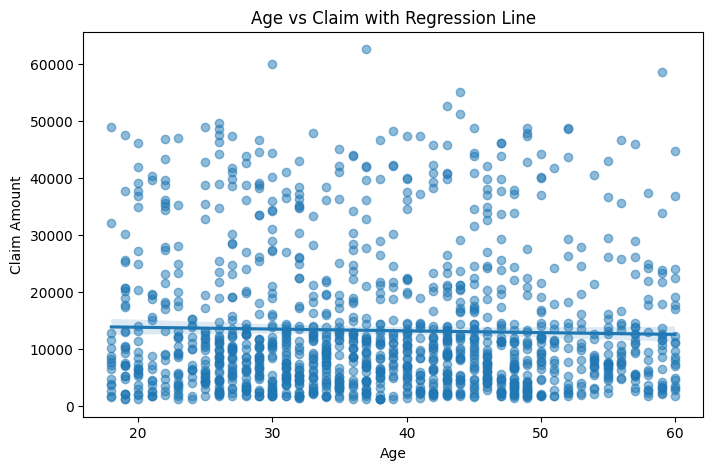

In [18]:
plt.figure(figsize=(8,5))
sns.regplot(x="age", y="claim", data=df_clean, scatter_kws={'alpha':0.5})
plt.title("Age vs Claim with Regression Line")
plt.xlabel("Age")
plt.ylabel("Claim Amount")
plt.show()


C:\Users\Ali\AppData\Local\Temp\ipykernel_9944\2442716557.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



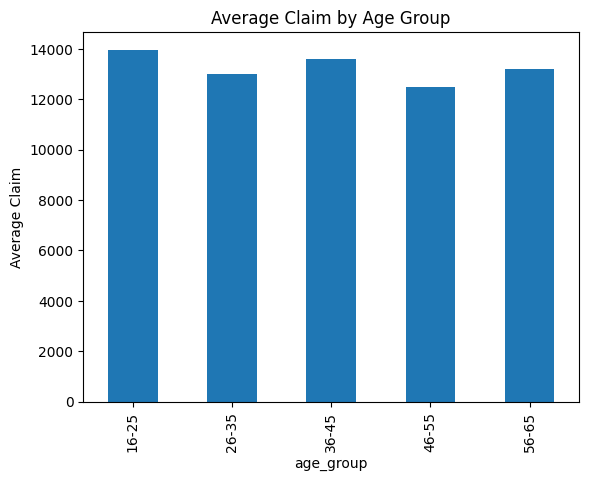

In [20]:
df_clean.groupby("age_group")["claim"].mean().plot(kind="bar")
plt.title("Average Claim by Age Group")
plt.ylabel("Average Claim")
plt.show()


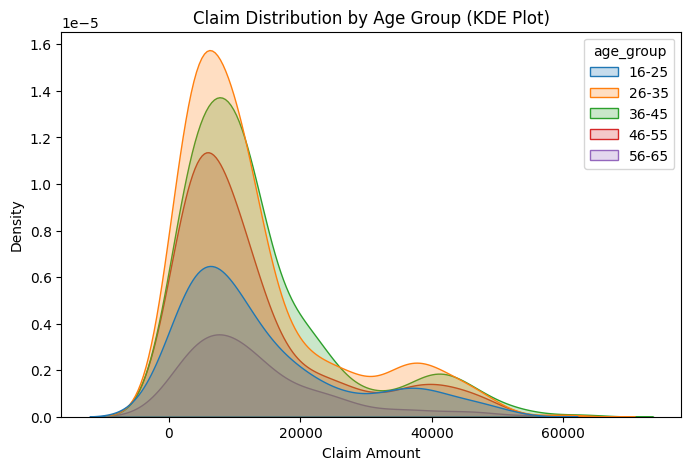

In [22]:
plt.figure(figsize=(8,5))

sns.kdeplot(data=df_clean, x="claim", hue="age_group", fill=True)

plt.title("Claim Distribution by Age Group (KDE Plot)")
plt.xlabel("Claim Amount")
plt.ylabel("Density")
plt.show()



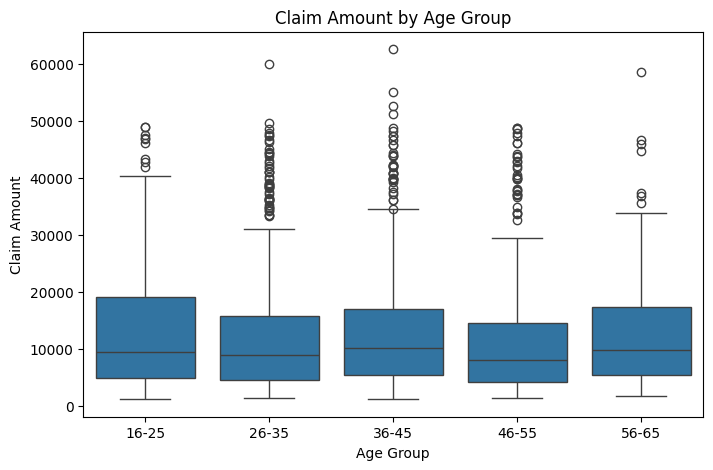

In [19]:
# Create age groups
df_clean["age_group"] = pd.cut(df_clean["age"],
                                bins=[15,25,35,45,55,65],
                                labels=["16-25","26-35","36-45","46-55","56-65"])

plt.figure(figsize=(8,5))
sns.boxplot(x="age_group", y="claim", data=df_clean)
plt.title("Claim Amount by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Claim Amount")
plt.show()


# Deep Bivariate Analysis – Age vs Claim

## 1️⃣ Claim Magnitude & Risk (Bar & Box Plot Insights)

### Highest Financial Risk

The 16–25 age group shows the highest *average* claim amount (~$14,000).  
Although this group does not generate the highest number of claims, when claims occur, they tend to be more expensive.

### Stability of the Typical Claim

Despite variation in averages, the median claim remains relatively stable across age groups (approximately $8k–$10k).

This indicates that:
- The higher averages are driven by extreme high-value cases.
- Most individuals across all age groups generate similar “standard” claim amounts.
- Mean alone may be misleading due to skewness.

---

## 2️⃣ Distribution & Frequency (KDE Insights)

### Volume Drivers

The 26–35 and 36–45 age groups generate the highest number of claims.
Their KDE peaks are strongest in the $0–$15k range, indicating:

- Higher claim frequency
- Mostly minor to moderate claim amounts

### Bimodal Distribution

Across all age groups, two clear peaks appear:

- A standard claim peak around ~$8k
- A major event peak around ~$40k

This suggests that age does not change the *type* of claim, but rather the *frequency* and likelihood* of higher-cost events.

---

## 3️⃣ Data Shape & Outlier Behavior

### High Volatility

All age groups show:
- Strong right skewness
- Significant high-value outliers (some exceeding $60,000)

This confirms the presence of rare but financially impactful cases.

### 36–45 Age Group Exception

Although this group does not have the highest average,
it contains some of the most extreme individual claim values in the dataset.

---

# Final Strategic Conclusion

Age influences:

- Claim frequency
- Average claim magnitude

However, it does NOT fundamentally change the type of claims being made.

The dataset demonstrates a U-shaped risk profile:

- Youngest group (16–25): Higher average cost per claim
- Middle-aged groups (26–45): Highest claim volume
- Older group (56–65): Elevated average risk again

Because the data is heavily skewed and bimodal:

Using the mean alone for premium pricing would be misleading.

Insurance pricing strategy should consider:
- High-probability standard claims
- Low-probability, high-cost catastrophic claims

Both types exist across all age groups.


# Bivariate Analysis – Smoker vs Claim

Objective:

To examine whether smoking status significantly impacts insurance claim amounts.

Smoking is medically associated with higher health risks,
so we expect smokers to generate higher claim amounts.


In [5]:
df_clean.head()

,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
0,39,male,23.2,91,Yes,0,No,southeast,1121.87
1,24,male,30.1,87,No,0,No,southeast,1131.51
2,38,male,33.3,82,Yes,0,No,southeast,1135.94
3,38,male,33.7,80,No,0,No,northwest,1136.40
4,38,male,34.1,100,No,0,No,northwest,1137.01


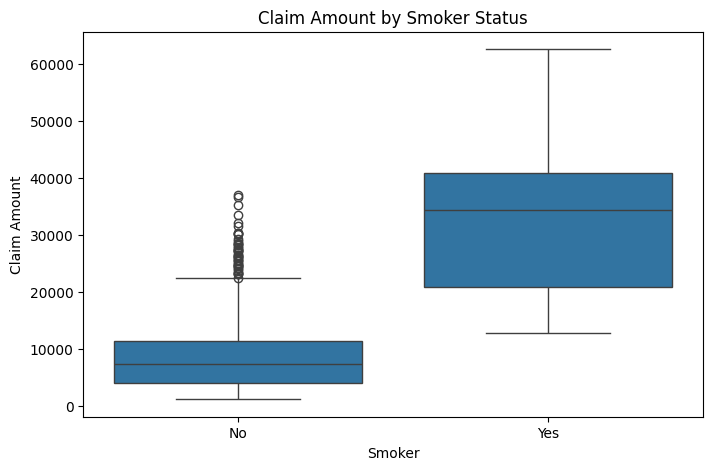

In [7]:
plt.figure(figsize=(8,5))
sns.boxplot(x="smoker", y="claim", data=df_clean)
plt.title("Claim Amount by Smoker Status")
plt.xlabel("Smoker")
plt.ylabel("Claim Amount")
plt.show()


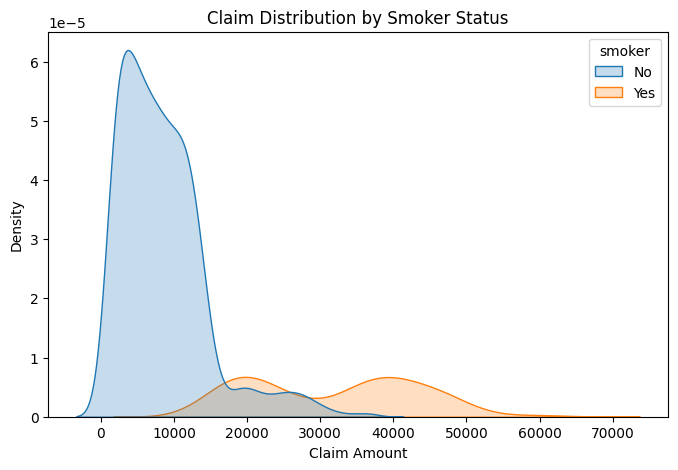

In [8]:
plt.figure(figsize=(8,5))
sns.kdeplot(data=df_clean, x="claim", hue="smoker", fill=True)
plt.title("Claim Distribution by Smoker Status")
plt.xlabel("Claim Amount")
plt.show()


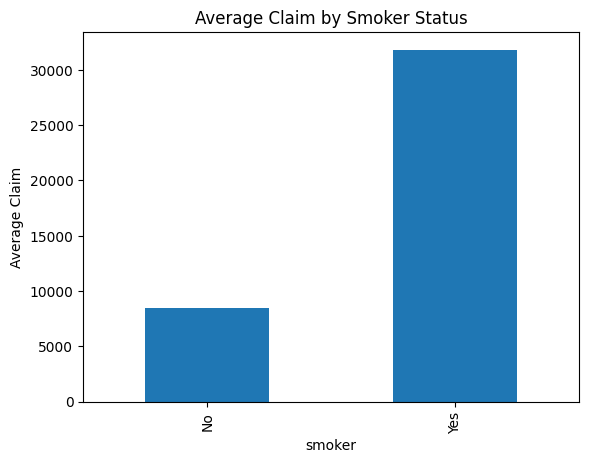

In [6]:
df_clean.groupby("smoker")["claim"].mean().plot(kind="bar")
plt.title("Average Claim by Smoker Status")
plt.ylabel("Average Claim")
plt.show()


## Smoker vs Claim – Key Findings

1. Smokers have significantly higher average claim amounts compared to non-smokers.
2. The distribution for smokers is shifted toward higher claim values.
3. Smokers show greater variability and more extreme high-cost cases.
4. Non-smokers mostly cluster around lower claim ranges.

Conclusion:

Smoking status is one of the strongest predictors of insurance claim cost.
Insurance companies should consider smoking behavior as a major risk factor when pricing premiums.


# Bivariate Analysis – Diabetic vs Claim

Objective:

To analyze whether diabetic individuals generate higher insurance claim amounts compared to non-diabetic individuals.

Since diabetes is a chronic condition, it is expected to increase medical costs.


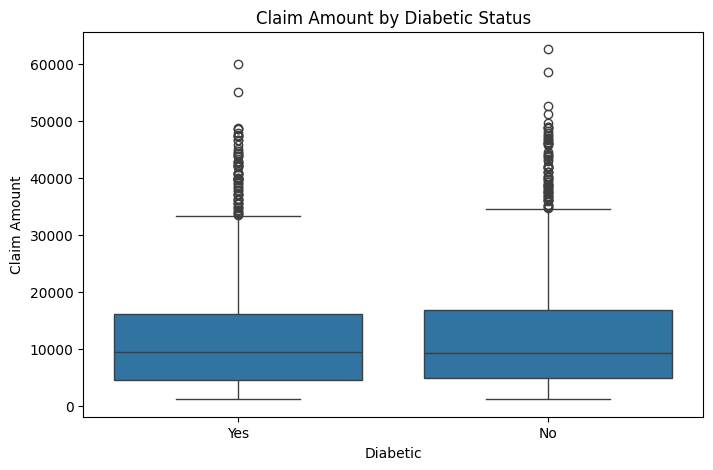

In [10]:
plt.figure(figsize=(8,5))
sns.boxplot(x="diabetic", y="claim", data=df_clean)
plt.title("Claim Amount by Diabetic Status")
plt.xlabel("Diabetic")
plt.ylabel("Claim Amount")
plt.show()


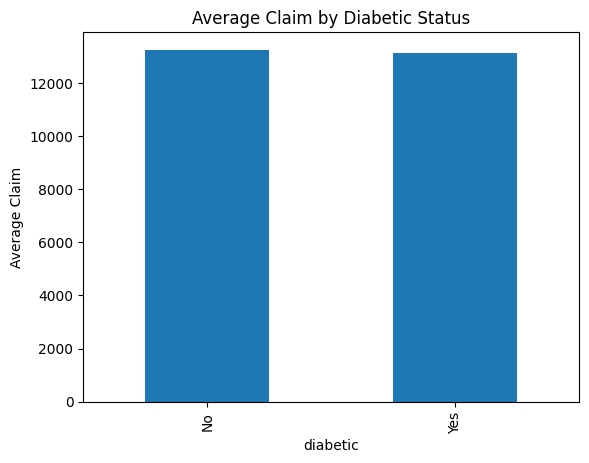

In [11]:
df_clean.groupby("diabetic")["claim"].mean().plot(kind="bar")
plt.title("Average Claim by Diabetic Status")
plt.ylabel("Average Claim")
plt.show()


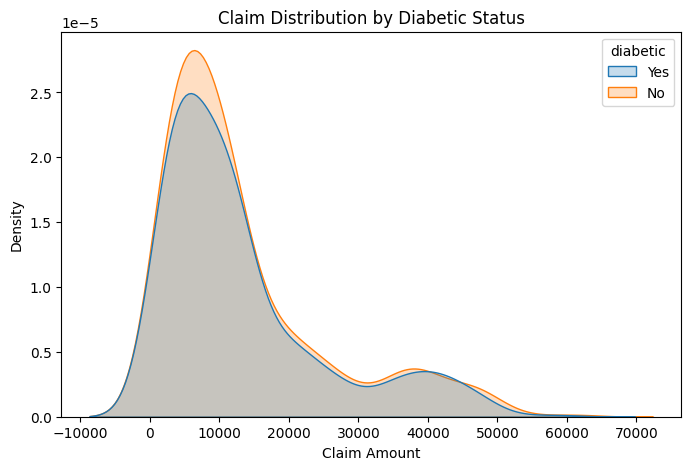

In [12]:
plt.figure(figsize=(8,5))
sns.kdeplot(data=df_clean, x="claim", hue="diabetic", fill=True)
plt.title("Claim Distribution by Diabetic Status")
plt.xlabel("Claim Amount")
plt.show()


## Diabetic vs Claim – Final Conclusion

The comparison between diabetic and non-diabetic individuals shows:

- Claim distributions are highly similar in shape.
- Median claim amounts are nearly identical.
- Both groups show heavy right-skewness and extreme outliers.
- No strong separation is visible between the two categories.

Conclusion:

Diabetic status does not appear to be a dominant driver of insurance claim amount in this dataset.
Other variables such as smoking status or BMI may have a stronger influence on claim magnitude.


# Bivariate Analysis – BMI vs Claim

Objective:

To examine whether higher Body Mass Index (BMI) is associated with higher insurance claim amounts.

Since obesity increases the risk of chronic diseases,
we expect a positive relationship between BMI and claim amount.


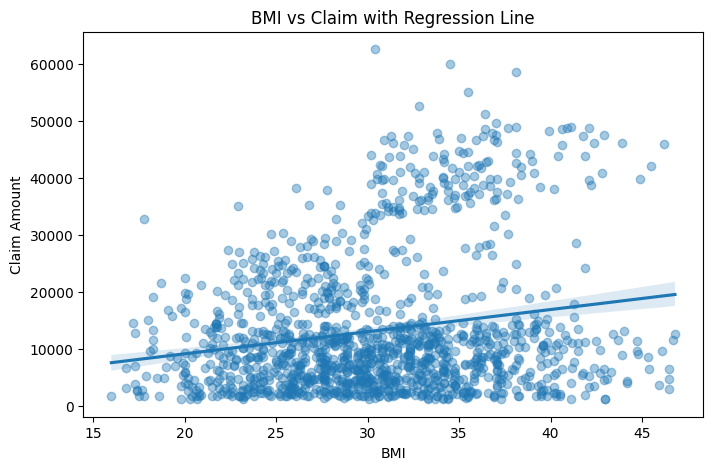

In [7]:
plt.figure(figsize=(8,5))
sns.regplot(x="bmi", y="claim", data=df_clean, scatter_kws={'alpha':0.4})
plt.title("BMI vs Claim with Regression Line")
plt.xlabel("BMI")
plt.ylabel("Claim Amount")
plt.show()


In [8]:
df_clean["bmi"].corr(df_clean["claim"])


np.float64(0.19219030327119518)

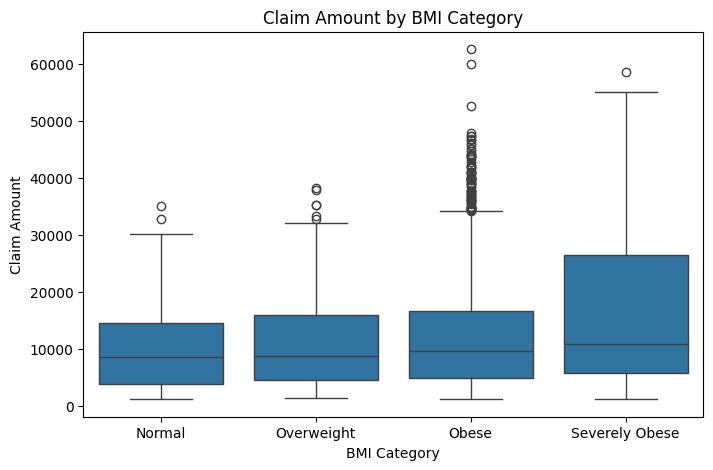

In [9]:
df_clean["bmi_group"] = pd.cut(df_clean["bmi"],
                               bins=[15,25,30,35,60],
                               labels=["Normal","Overweight","Obese","Severely Obese"])

plt.figure(figsize=(8,5))
sns.boxplot(x="bmi_group", y="claim", data=df_clean)
plt.title("Claim Amount by BMI Category")
plt.xlabel("BMI Category")
plt.ylabel("Claim Amount")
plt.show()


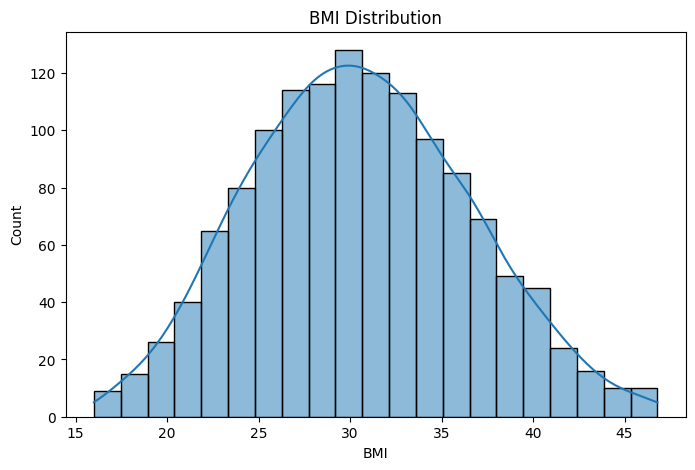

In [17]:
plt.figure(figsize=(8,5))
sns.histplot(df_clean["bmi"], kde=True)
plt.title("BMI Distribution")
plt.xlabel("BMI")
plt.show()


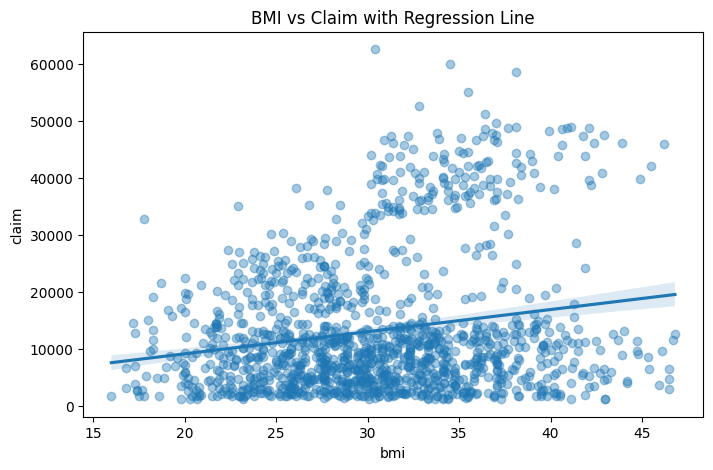

In [18]:
plt.figure(figsize=(8,5))
sns.regplot(x="bmi", y="claim", data=df_clean,
            scatter_kws={"alpha":0.4})
plt.title("BMI vs Claim with Regression Line")
plt.show()


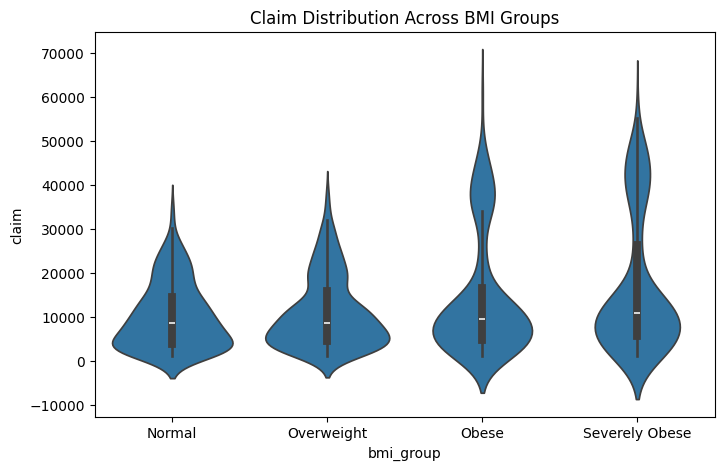

In [19]:
plt.figure(figsize=(8,5))
sns.violinplot(x="bmi_group", y="claim", data=df_clean)
plt.title("Claim Distribution Across BMI Groups")
plt.show()


```markdown
# Insurance Claim Analysis: BMI Category vs. Claim Amount

## Key Observations

- **Positive Correlation**: As BMI increases from **Normal** to **Severely Obese**, there is a general upward trend in the claim amounts.

- **Median Values**: The median claim amount increases progressively across BMI categories, with the **Severely Obese** group having the highest median at approximately **$11,000**.

- **Variability**: The **Severely Obese** category shows the greatest variability (the largest box and longest whiskers), indicating a much wider range of claim amounts compared to other groups.

- **Outliers**: All categories have high-value outliers (values above the whiskers), but the **Obese** category features a significant cluster of extreme outliers, with some claims exceeding **$60,000**.

---

## Summary Table

| BMI Category   | Approximate Median | Distribution Range | Notable Features                               |
|----------------|-------------------|-------------------|------------------------------------------------|
| **Normal**     | ~$8,500           | Narrowest         | Fewest high-value outliers                     |
| **Overweight** | ~$9,000           | Moderate          | Slightly higher reach than Normal              |
| **Obese**      | ~$10,000          | Moderate          | Highest number of extreme outliers             |
| **Severely Obese** | ~$11,000      | Widest            | Largest overall spread and highest maximums    |

---

## Business Implications

1. **Risk-Based Pricing**: BMI appears to be a meaningful predictor of claim severity, with higher BMI categories correlating with higher claim amounts and greater variability.

2. **Outlier Concentration**: The **Obese** category's cluster of extreme outliers (>$60,000) warrants further investigation to understand what drives these exceptionally high claims.

3. **Underwriting Considerations**: The progressive increase in both median claims and variability suggests that BMI could be a valuable factor in risk assessment models.

```

### Gender vs Claim Analysis

Bivariate analysis was performed to understand the relationship between gender and insurance claim amount.

Several visualizations including box plots, violin plots, KDE plots, and bar charts were used to compare claim distributions between males and females.

The analysis shows that male policyholders tend to have slightly higher average claim amounts compared to female policyholders. The distribution plots indicate that males also exhibit a wider spread of claim values.

However, the difference between genders is not extremely large, suggesting that gender alone is not a strong predictor of claim amount.

Other variables such as age, BMI, and smoking status are likely to have a stronger influence on insurance claims.


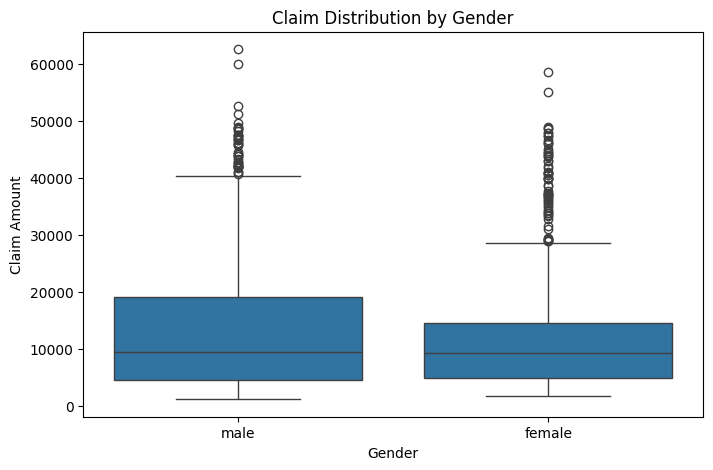

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(x="gender", y="claim", data= df_clean)

plt.title("Claim Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Claim Amount")

plt.show()


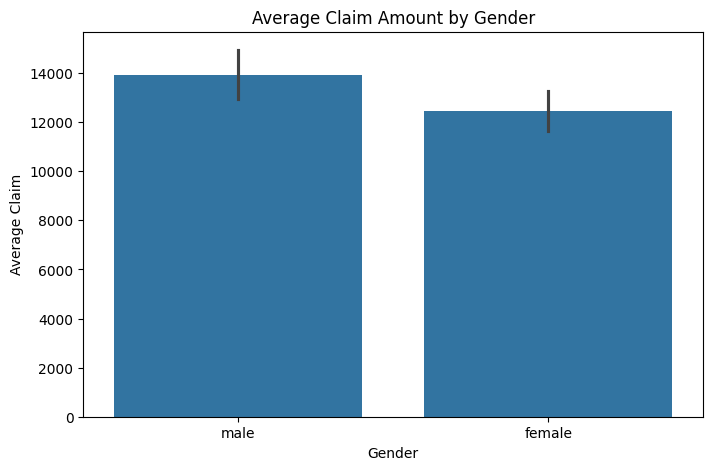

In [14]:
plt.figure(figsize=(8,5))
sns.barplot(x="gender", y="claim", data=df_clean)

plt.title("Average Claim Amount by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Claim")

plt.show()


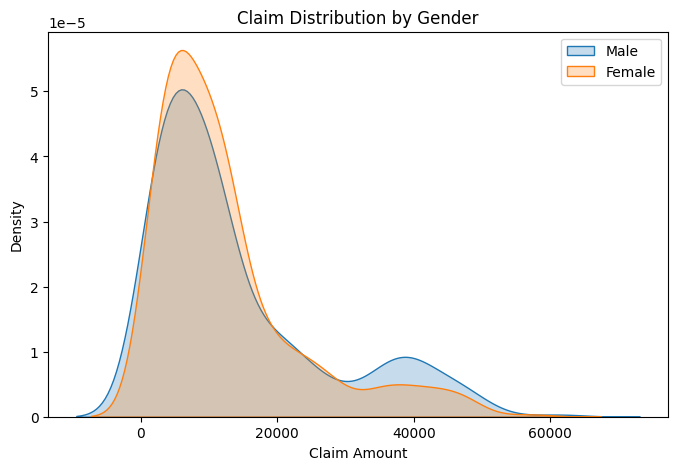

In [15]:
plt.figure(figsize=(8,5))

sns.kdeplot(df_clean[df_clean["gender"]=="male"]["claim"], label="Male", fill=True)
sns.kdeplot(df_clean[df_clean["gender"]=="female"]["claim"], label="Female", fill=True)

plt.title("Claim Distribution by Gender")
plt.xlabel("Claim Amount")
plt.ylabel("Density")

plt.legend()
plt.show()


In [18]:
df_clean.groupby("gender")["claim"].mean()


gender
female    12445.742580
male      13929.019122
Name: claim, dtype: float64

### Gender vs Claim Analysis

Bivariate analysis was performed to understand the relationship between gender and insurance claim amount.

Several visualizations including box plots, violin plots, KDE plots, and bar charts were used to compare claim distributions between males and females.

The analysis shows that male policyholders tend to have slightly higher average claim amounts compared to female policyholders. The distribution plots indicate that males also exhibit a wider spread of claim values.

However, the difference between genders is not extremely large, suggesting that gender alone is not a strong predictor of claim amount.

Other variables such as age, BMI, and smoking status are likely to have a stronger influence on insurance claims.


## region vs claim

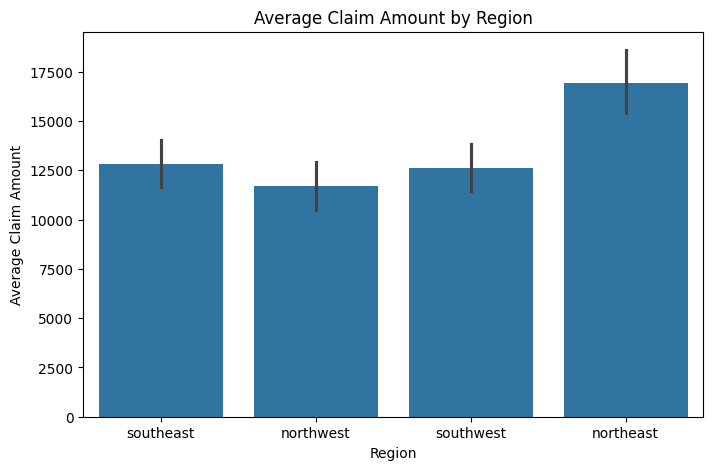

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.barplot(x="region", y="claim", data=df_clean)

plt.title("Average Claim Amount by Region")
plt.xlabel("Region")
plt.ylabel("Average Claim Amount")

plt.show()


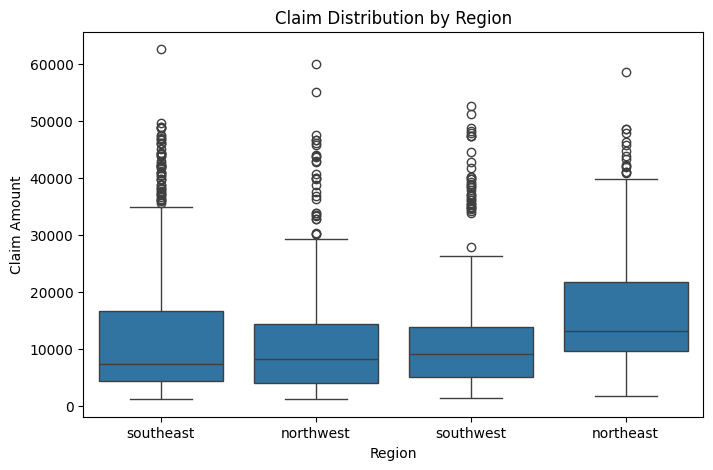

In [21]:
plt.figure(figsize=(8,5))
sns.boxplot(x="region", y="claim", data=df_clean)

plt.title("Claim Distribution by Region")
plt.xlabel("Region")
plt.ylabel("Claim Amount")

plt.show()


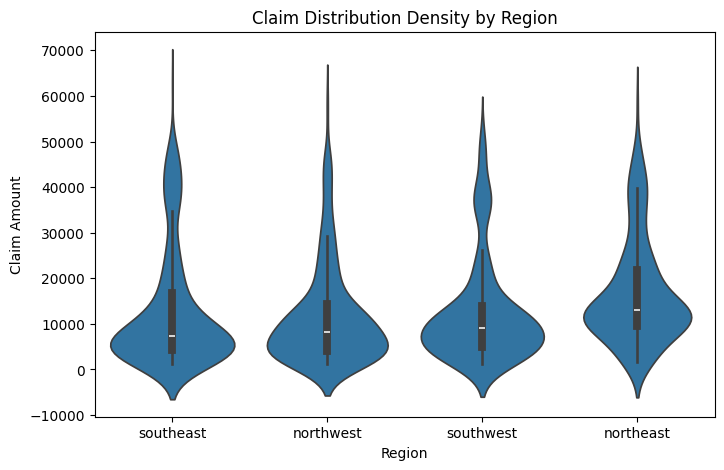

In [22]:
plt.figure(figsize=(8,5))
sns.violinplot(x="region", y="claim", data=df_clean)

plt.title("Claim Distribution Density by Region")
plt.xlabel("Region")
plt.ylabel("Claim Amount")

plt.show()


In [24]:
df_clean.groupby("region")["claim"].mean()


region
northeast    16921.462609
northwest    11702.285661
southeast    12838.100318
southwest    12616.451310
Name: claim, dtype: float64

In [25]:
df_clean.groupby("region")["claim"].describe()


,count,mean,std,min,25%,50%,75%,max
region,,,,,,,,
northeast,230.0,16921.462609,11592.842321,1694.80,9560.6900,13136.470,21743.4875,58571.07
northwest,348.0,11702.285661,11033.174912,1136.40,4052.0925,8139.495,14255.0050,60021.40
southeast,440.0,12838.100318,12933.288559,1121.87,4350.2475,7283.770,16700.7100,62592.87
southwest,313.0,12616.451310,11441.455882,1261.44,5012.4700,9101.800,13822.8000,52590.83


### Region vs Claim Analysis

Bivariate analysis was conducted to examine the relationship between geographical region and insurance claim amounts.

Several visualizations such as bar plots, box plots, and violin plots were used to understand how claims vary across different regions.

The bar chart shows the average claim amount for each region, while the box plot and violin plot provide insights into the distribution and variability of claims.

From the analysis, it can be observed that some regions tend to have slightly higher claim amounts compared to others. However, the difference is not very large, indicating that region alone may not significantly influence the claim amount.

Other factors such as smoking status, age, and BMI may have a stronger impact on insurance costs compared to geographical location.


### Region vs Claim Analysis

To understand the relationship between geographical location and insurance charges, a bivariate analysis was performed between the `region` variable and the `claim` amount.

The statistical summary shows that claim amounts vary slightly across different regions.

The **Northeast region** has the highest average claim amount (≈16921), while the **Northwest region** has the lowest average claim amount (≈11702). This indicates that customers in the Northeast tend to have higher insurance costs on average.

The **Southeast region** recorded the highest maximum claim (≈62592), suggesting that some extremely high insurance expenses occur in this region.

Additionally, the **Southwest region shows the highest standard deviation**, meaning claim values are more spread out and vary significantly among individuals in that region.

Overall, although there are differences in average claims across regions, the variation is not extremely large. This suggests that **region alone is not a strong predictor of insurance charges**, and other variables such as smoking status, BMI, and age likely have a stronger impact on insurance costs.
